# AI Chest X-Ray Diagnosis Assistant (NIH ChestX-ray14)

Multi-label deep learning model that takes a chest X-ray image as input and
predicts the probability of **14 thoracic pathologies**, with a Grad-CAM
heatmap showing which region of the image drove each prediction.

**Architecture:** DenseNet-121 (ImageNet-pretrained) with a 14-way sigmoid
output head — the same backbone used in the CheXNet paper (Rajpurkar et al.,
2017), which was the first model to match/exceed radiologist performance on
several findings in this exact dataset.

**Pathologies detected:** Atelectasis, Cardiomegaly, Effusion, Infiltration,
Mass, Nodule, Pneumonia, Pneumothorax, Consolidation, Edema, Emphysema,
Fibrosis, Pleural_Thickening, Hernia.

---
### ⚠️ Run this on Kaggle Notebooks or Google Colab (GPU + internet required)
This notebook needs: internet access (to download ~42GB via `kagglehub`), a
GPU, and `torch`/`torchvision`. **Kaggle Notebooks are the easiest place to
run it** — kagglehub works natively there, a free GPU is one click away
(Settings → Accelerator → GPU), and since the dataset lives on Kaggle's own
infrastructure the download is fast.

### ⚠️ Medical disclaimer
This is a research / decision-support project, **not** a certified medical
device. Every flagged finding must be reviewed by a qualified radiologist
before any real diagnostic or treatment decision. Do not use this to
diagnose yourself or anyone else.


## 1. Download the dataset

In [1]:
# If kagglehub isn't preinstalled: !pip install -q kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nih-chest-xrays/data")
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/datasets/organizations/nih-chest-xrays/data


**Tip — for a fast first run:** the NIH archive also ships a `sample/`
subfolder with `sample_labels.csv` and ~5,600 images (~1GB) instead of the
full 112,120 images (~42GB). If you just want to verify the pipeline works
end-to-end before committing to a multi-hour full training run, point
`DATA_ROOT` at that subfolder first, then re-run against the full `path`
once you've confirmed everything works.

In [2]:
import os
DATA_ROOT = path  # or e.g. os.path.join(path, "sample") for the quick-start subset

print("Top-level contents:")
for item in sorted(os.listdir(DATA_ROOT))[:20]:
    print(" -", item)


Top-level contents:
 - ARXIV_V5_CHESTXRAY.pdf
 - BBox_List_2017.csv
 - Data_Entry_2017.csv
 - FAQ_CHESTXRAY.pdf
 - LOG_CHESTXRAY.pdf
 - README_CHESTXRAY.pdf
 - images_001
 - images_002
 - images_003
 - images_004
 - images_005
 - images_006
 - images_007
 - images_008
 - images_009
 - images_010
 - images_011
 - images_012
 - test_list.txt
 - train_val_list.txt


## 2. Install / import dependencies

In [3]:
# On Kaggle/Colab these are usually preinstalled; uncomment if needed:
# !pip install -q torch torchvision scikit-learn

import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 3. Data preparation

Parses `Data_Entry_2017.csv`, builds multi-hot labels for the 14 pathologies,
and applies the dataset's **official patient-level train/val/test split**
(`train_val_list.txt` / `test_list.txt`) so no patient's X-rays leak across
splits — a patient can have several scans, and splitting by image instead of
by patient would silently inflate validation performance.

In [4]:
PATHOLOGIES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass",
    "Nodule", "Pneumonia", "Pneumothorax", "Consolidation", "Edema",
    "Emphysema", "Fibrosis", "Pleural_Thickening", "Hernia",
]
NUM_CLASSES = len(PATHOLOGIES)


def build_image_index(dataset_root):
    index = {}
    for path_ in glob.glob(os.path.join(dataset_root, "images_*", "images", "*.png")):
        index[os.path.basename(path_)] = path_
    if not index:
        for path_ in glob.glob(os.path.join(dataset_root, "**", "*.png"), recursive=True):
            index[os.path.basename(path_)] = path_
    return index


def parse_labels(entry_csv_path):
    df = pd.read_csv(entry_csv_path)
    df = df.rename(columns={"Image Index": "image_index", "Patient ID": "patient_id"})

    label_matrix = np.zeros((len(df), NUM_CLASSES), dtype=np.float32)
    for i, findings in enumerate(df["Finding Labels"].fillna("No Finding")):
        for disease in findings.split("|"):
            disease = disease.strip()
            if disease in PATHOLOGIES:
                label_matrix[i, PATHOLOGIES.index(disease)] = 1.0

    for j, name in enumerate(PATHOLOGIES):
        df[name] = label_matrix[:, j]
    df["no_finding"] = (label_matrix.sum(axis=1) == 0).astype(np.float32)
    return df[["image_index", "patient_id"] + PATHOLOGIES + ["no_finding"]]


def apply_official_split(df, dataset_root):
    train_val_path = os.path.join(dataset_root, "train_val_list.txt")
    test_path = os.path.join(dataset_root, "test_list.txt")

    if os.path.exists(train_val_path) and os.path.exists(test_path):
        with open(train_val_path) as f:
            train_val_names = set(l.strip() for l in f if l.strip())
        with open(test_path) as f:
            test_names = set(l.strip() for l in f if l.strip())

        train_val_df = df[df["image_index"].isin(train_val_names)].reset_index(drop=True)
        test_df = df[df["image_index"].isin(test_names)].reset_index(drop=True)

        rng = np.random.RandomState(42)
        patients = train_val_df["patient_id"].unique()
        rng.shuffle(patients)
        n_val = max(1, int(0.1 * len(patients)))
        val_patients = set(patients[:n_val])

        val_df = train_val_df[train_val_df["patient_id"].isin(val_patients)].reset_index(drop=True)
        train_df = train_val_df[~train_val_df["patient_id"].isin(val_patients)].reset_index(drop=True)
        return train_df, val_df, test_df

    # Fallback: patient-level random split (e.g. when using the 'sample' subset,
    # which doesn't ship its own train_val_list.txt/test_list.txt)
    rng = np.random.RandomState(42)
    patients = df["patient_id"].unique()
    rng.shuffle(patients)
    n = len(patients)
    train_p = set(patients[: int(0.8 * n)])
    val_p = set(patients[int(0.8 * n): int(0.9 * n)])
    test_p = set(patients[int(0.9 * n):])
    train_df = df[df["patient_id"].isin(train_p)].reset_index(drop=True)
    val_df = df[df["patient_id"].isin(val_p)].reset_index(drop=True)
    test_df = df[df["patient_id"].isin(test_p)].reset_index(drop=True)
    return train_df, val_df, test_df


def compute_class_pos_weights(train_df):
    weights = np.zeros(NUM_CLASSES, dtype=np.float32)
    n = len(train_df)
    for j, name in enumerate(PATHOLOGIES):
        n_pos = train_df[name].sum()
        weights[j] = ((n - n_pos) / n_pos) if n_pos > 0 else 1.0
    return weights


entry_csv = os.path.join(DATA_ROOT, "Data_Entry_2017.csv")
df = parse_labels(entry_csv)
train_df, val_df, test_df = apply_official_split(df, DATA_ROOT)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

image_index = build_image_index(DATA_ROOT)
print(f"Indexed {len(image_index)} image files")


Train: 77994  Val: 8530  Test: 25596
Indexed 112120 image files


## 4. Exploratory data analysis: label frequency

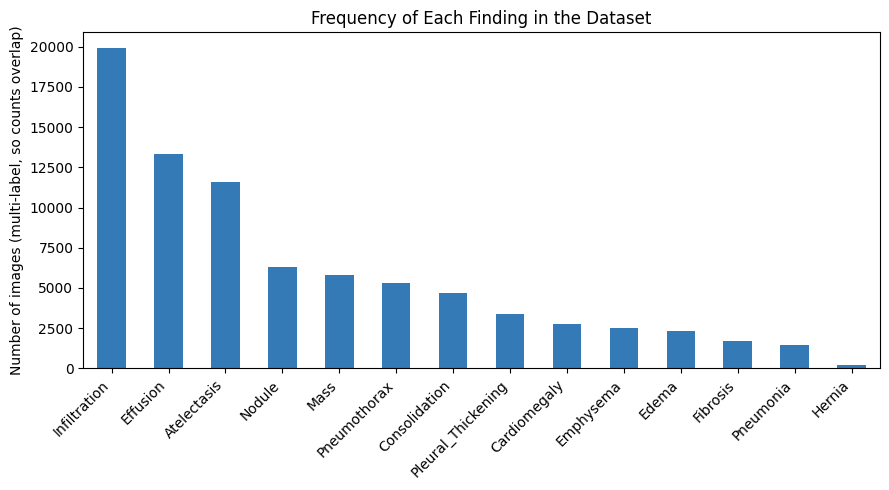

'No Finding' images: 60361 (53.8%)


In [5]:
label_counts = df[PATHOLOGIES].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
label_counts.plot(kind="bar", color="#337ab7")
plt.title("Frequency of Each Finding in the Dataset")
plt.ylabel("Number of images (multi-label, so counts overlap)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"'No Finding' images: {int(df['no_finding'].sum())} ({df['no_finding'].mean():.1%})")


Note the severe class imbalance (e.g. Hernia appears in well under 1% of
images while Infiltration appears in ~18%) — this is why training uses a
per-class weighted loss (`compute_class_pos_weights`) rather than plain
binary cross-entropy.

## 5. Dataset & DataLoaders

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224


def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=7),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_index_map, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_index = image_index_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(self.image_index[row["image_index"]]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        labels = row[PATHOLOGIES].values.astype(np.float32)
        return image, labels


BATCH_SIZE = 32  # reduce to 8-16 if you hit GPU memory limits

train_ds = ChestXrayDataset(train_df, image_index, get_transforms(train=True))
val_ds = ChestXrayDataset(val_df, image_index, get_transforms(train=False))
test_ds = ChestXrayDataset(test_df, image_index, get_transforms(train=False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), " Val batches:", len(val_loader), " Test batches:", len(test_loader))


Train batches: 2438  Val batches: 267  Test batches: 800


## 6. Model: DenseNet-121 with a 14-way multi-label head

In [7]:
class ChestXrayModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.densenet121(weights=weights)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)  # raw logits - apply sigmoid at inference time


model = ChestXrayModel(pretrained=True).to(device)
print(model.backbone.classifier)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 149MB/s]


Linear(in_features=1024, out_features=14, bias=True)


## 7. Training

Uses `BCEWithLogitsLoss` with per-class `pos_weight` to counter class
imbalance, `AdamW`, and `ReduceLROnPlateau` keyed on validation mean AUC.
Saves the best checkpoint (by validation AUC) to `chest_xray_model.pt`.

**A full run (112k images) takes roughly 1-3 hours per epoch on a single
Kaggle/Colab GPU** depending on batch size — start with `EPOCHS = 3-5` to
confirm everything works, then increase. If you're using the `sample/`
subset (~5,600 images) a full run of 15-20 epochs takes only minutes.

In [8]:
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())
    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels)
    probs = 1 / (1 + np.exp(-logits))

    aucs = {}
    for j, name in enumerate(PATHOLOGIES):
        if len(np.unique(labels[:, j])) > 1:
            aucs[name] = roc_auc_score(labels[:, j], probs[:, j])
        else:
            aucs[name] = float("nan")
    return np.nanmean(list(aucs.values())), aucs


EPOCHS = 10  # increase once you've confirmed the pipeline runs end-to-end
LR = 1e-4

pos_weight = torch.tensor(compute_class_pos_weights(train_df), device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

best_auc = -1.0
for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_ds)
    mean_auc, per_class_auc = evaluate(model, val_loader)
    scheduler.step(mean_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_mean_AUC={mean_auc:.4f} | "
          f"time={time.time()-t0:.1f}s")

    if mean_auc > best_auc:
        best_auc = mean_auc
        torch.save(model.state_dict(), "chest_xray_model.pt")
        print(f"  -> saved new best model (val_mean_AUC={best_auc:.4f})")


Epoch 01 | train_loss=1.1259 | val_mean_AUC=0.7856 | time=1721.4s
  -> saved new best model (val_mean_AUC=0.7856)
Epoch 02 | train_loss=1.0245 | val_mean_AUC=0.7963 | time=1373.6s
  -> saved new best model (val_mean_AUC=0.7963)
Epoch 03 | train_loss=0.9805 | val_mean_AUC=0.8094 | time=1351.3s
  -> saved new best model (val_mean_AUC=0.8094)
Epoch 04 | train_loss=0.9436 | val_mean_AUC=0.8190 | time=1333.3s
  -> saved new best model (val_mean_AUC=0.8190)
Epoch 05 | train_loss=0.9222 | val_mean_AUC=0.8272 | time=1324.7s
  -> saved new best model (val_mean_AUC=0.8272)
Epoch 06 | train_loss=0.8876 | val_mean_AUC=0.8193 | time=1363.0s
Epoch 07 | train_loss=0.8646 | val_mean_AUC=0.8266 | time=1379.4s
Epoch 08 | train_loss=0.8323 | val_mean_AUC=0.8279 | time=1428.8s
  -> saved new best model (val_mean_AUC=0.8279)
Epoch 09 | train_loss=0.8156 | val_mean_AUC=0.8308 | time=1402.9s
  -> saved new best model (val_mean_AUC=0.8308)
Epoch 10 | train_loss=0.7806 | val_mean_AUC=0.8178 | time=1344.7s


## 8. Final evaluation on the held-out test set

In [9]:
model.load_state_dict(torch.load("chest_xray_model.pt"))
test_mean_auc, test_per_class_auc = evaluate(model, test_loader)

print(f"Final TEST mean AUC: {test_mean_auc:.4f}\n")
for name, auc in sorted(test_per_class_auc.items(), key=lambda x: -(x[1] if x[1] == x[1] else 0)):
    print(f"  {name:20s} AUC={auc:.4f}")


Final TEST mean AUC: 0.8023

  Hernia               AUC=0.9251
  Emphysema            AUC=0.9022
  Cardiomegaly         AUC=0.8844
  Pneumothorax         AUC=0.8524
  Edema                AUC=0.8407
  Effusion             AUC=0.8174
  Fibrosis             AUC=0.8141
  Mass                 AUC=0.8136
  Pleural_Thickening   AUC=0.7613
  Atelectasis          AUC=0.7572
  Nodule               AUC=0.7446
  Consolidation        AUC=0.7424
  Pneumonia            AUC=0.6969
  Infiltration         AUC=0.6795


## 9. Model accuracy: precision, recall, F1 (in addition to AUC)

AUC (above) measures ranking quality across all thresholds, but doesn't
directly say "how often is a flagged finding actually correct" at the
operating threshold you'll actually use. This section reports per-class
**accuracy, precision, recall, and F1 at threshold = 0.5**, plus two
summary numbers:
- **Mean per-label accuracy** — average, across the 14 independent
  yes/no calls, of how often each call is correct.
- **Exact-match accuracy** — the much stricter fraction of images where
  *all 14* labels are predicted correctly simultaneously. This is
  expected to be low for multi-label problems like this one — it's
  included for completeness, not as the headline metric.

In [10]:
from sklearn.metrics import precision_recall_fscore_support


def evaluate_accuracy(model, loader, threshold=0.5):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.numpy())
    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels)
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= threshold).astype(np.float32)

    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )
    per_class_acc = (preds == labels).mean(axis=0)

    results_df = pd.DataFrame({
        "pathology": PATHOLOGIES,
        "accuracy": per_class_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    }).sort_values("f1", ascending=False).reset_index(drop=True)

    exact_match_accuracy = (preds == labels).all(axis=1).mean()
    mean_per_label_accuracy = per_class_acc.mean()

    print(f"Mean per-label accuracy:  {mean_per_label_accuracy:.1%}")
    print(f"Exact-match accuracy (all 14 correct at once): {exact_match_accuracy:.1%}")
    print()
    return results_df


print("=== Test set accuracy @ threshold = 0.5 ===")
accuracy_df = evaluate_accuracy(model, test_loader, threshold=0.5)
accuracy_df


=== Test set accuracy @ threshold = 0.5 ===
Mean per-label accuracy:  69.3%
Exact-match accuracy (all 14 correct at once): 5.3%



,pathology,accuracy,precision,recall,f1,support
0,Effusion,0.603883,0.301887,0.896522,0.451679,4658
1,Infiltration,0.470386,0.292508,0.858475,0.436341,6112
2,Pneumothorax,0.681474,0.230822,0.882927,0.365969,2665
3,Atelectasis,0.632482,0.224262,0.759988,0.346328,3279
4,Cardiomegaly,0.878536,0.206559,0.671656,0.315952,1069
5,Mass,0.743905,0.172860,0.726545,0.279274,1748
6,Emphysema,0.778442,0.146759,0.870082,0.251155,1093
7,Nodule,0.739334,0.138376,0.595194,0.224547,1623
8,Consolidation,0.474254,0.108435,0.888154,0.193274,1815
9,Edema,0.682841,0.090981,0.864865,0.164643,925


## 10. Grad-CAM: visualizing *why* the model made a prediction

A probability score alone ("73% Cardiomegaly") isn't very trustworthy to a
clinician without knowing what drove it. Grad-CAM highlights the image
region the model relied on for a given prediction, so you can sanity-check
that it's looking at, e.g., the heart border for a cardiomegaly call — not
an unrelated artifact like a pacemaker lead or text label.

In [40]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        # Only a forward hook is needed on the module. We capture the
        # gradient via tensor.register_hook on a cloned activation instead
        # of a module-level register_full_backward_hook, because DenseNet's
        # forward() applies an in-place ReLU right after this layer, which
        # conflicts with full-backward-hooks (RuntimeError: 'Output ... is
        # a view and is being modified inplace').
        target_layer.register_forward_hook(self._save_activations)

    def _save_activations(self, module, inp, out):
        # clone() so this is a fresh tensor we can safely attach a hook to
        self.activations = out.clone()
        
        # Only register the backward hook if the tensor requires gradients
        if self.activations.requires_grad:
            self.activations.register_hook(self._save_gradients)
            
        # FIX: Return the clone so it replaces the original output in the graph!
        return self.activations
            
    def _save_gradients(self, grad):
        self.gradients = grad.detach()

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)
        logits = self.model(input_tensor)
        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


def overlay_heatmap(original_pil_image, cam, alpha=0.4):
    original = original_pil_image.convert("RGB").resize((cam.shape[1], cam.shape[0]))
    orig_arr = np.array(original).astype(np.float32)
    heatmap = np.zeros((*cam.shape, 3), dtype=np.float32)
    heatmap[..., 0] = 255 * cam
    heatmap[..., 1] = 255 * np.clip(cam - 0.5, 0, 1) * 2
    heatmap[..., 2] = 255 * np.clip(0.5 - cam, 0, 1) * 2
    blended = np.clip((1 - alpha) * orig_arr + alpha * heatmap, 0, 255).astype(np.uint8)
    return Image.fromarray(blended)


gradcam = GradCAM(model, model.backbone.features.norm5)
# Clear any lingering hooks from previous cell runs
model.backbone.features.norm5._forward_hooks.clear()

# Now attach the new, fixed hook
gradcam = GradCAM(model, model.backbone.features.norm5)


## 11. The diagnosis assistant — run it on a few test images

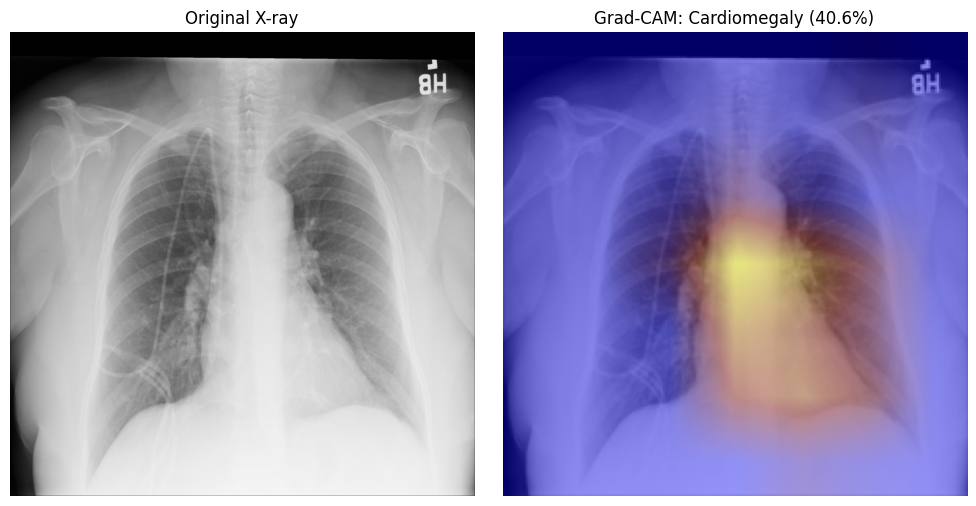

Top 5 findings:
  Cardiomegaly         40.6%
  Pleural_Thickening   30.8%
  Nodule               26.8%
  Infiltration         26.2%
  Emphysema            21.3%
Flagged (>=50%): none
--------------------------------------------------


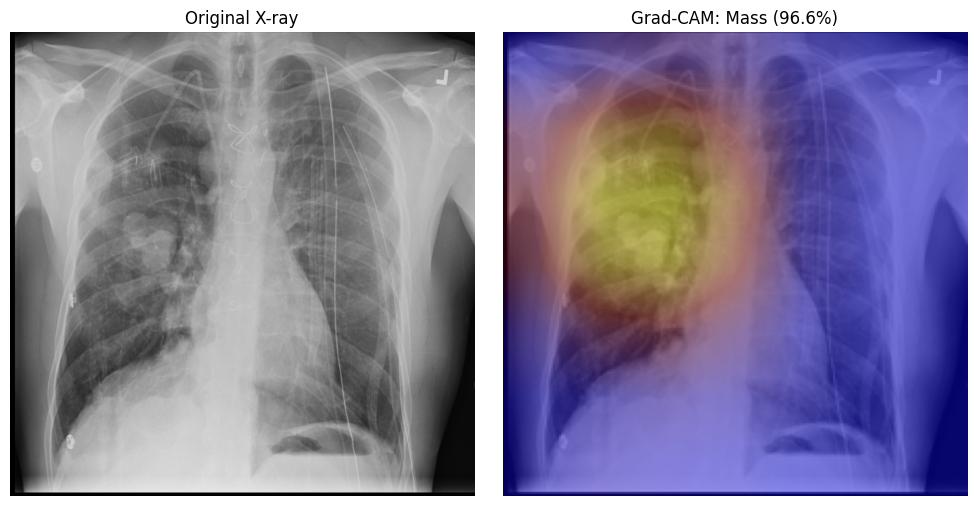

Top 5 findings:
  Mass                 96.6%
  Nodule               82.3%
  Hernia               70.6%
  Pneumothorax         53.0%
  Emphysema            35.6%
Flagged (>=50%): {'Mass': 0.9661009311676025, 'Nodule': 0.8234373331069946, 'Pneumothorax': 0.5298120975494385, 'Hernia': 0.7057381868362427}
--------------------------------------------------


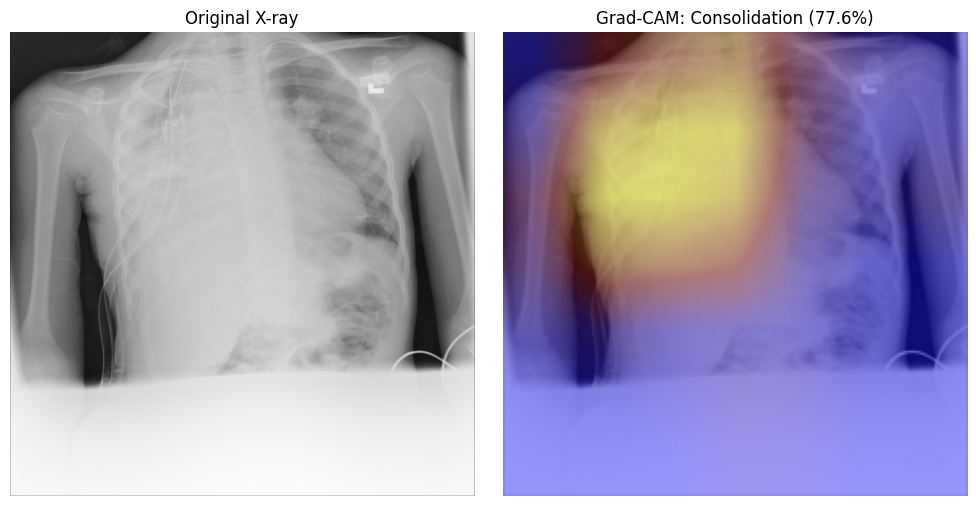

Top 5 findings:
  Consolidation        77.6%
  Effusion             72.3%
  Mass                 72.0%
  Pneumothorax         59.9%
  Pleural_Thickening   57.9%
Flagged (>=50%): {'Effusion': 0.7231204509735107, 'Mass': 0.7196035981178284, 'Pneumothorax': 0.5992865562438965, 'Consolidation': 0.7764962911605835, 'Emphysema': 0.5359129905700684, 'Fibrosis': 0.554683268070221, 'Pleural_Thickening': 0.5790212154388428}
--------------------------------------------------


In [41]:
def diagnose(image_path, threshold=0.5):
    pil_image = Image.open(image_path).convert("RGB")
    tensor = get_transforms(train=False)(pil_image).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.sigmoid(model(tensor)).cpu().numpy()[0]

    findings = {name: float(probs[i]) for i, name in enumerate(PATHOLOGIES)}
    flagged = {k: v for k, v in findings.items() if v >= threshold}
    top_idx = int(np.argmax(probs))

    cam = gradcam.generate(tensor, top_idx)
    overlay = overlay_heatmap(pil_image, cam)

    return {
        "findings": dict(sorted(findings.items(), key=lambda x: -x[1])),
        "flagged": flagged,
        "top_finding": PATHOLOGIES[top_idx],
        "top_probability": float(probs[top_idx]),
    }, pil_image, overlay


# Try it on a handful of real test-set images
import random
sample_rows = test_df.sample(n=min(3, len(test_df)), random_state=1)

for _, row in sample_rows.iterrows():
    img_path = image_index[row["image_index"]]
    result, original, overlay = diagnose(img_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM: {result['top_finding']} ({result['top_probability']:.1%})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print("Top 5 findings:")
    for name, p in list(result["findings"].items())[:5]:
        print(f"  {name:20s} {p:.1%}")
    print("Flagged (>=50%):", result["flagged"] or "none")
    print("-" * 50)


## 12. Test on your own X-ray image

Run the trained model on any chest X-ray you provide — not just images
from the NIH test split. Useful for sanity-checking on genuinely unseen
data.

- **Kaggle:** upload your image via *Add Data* (or drag it into
  `/kaggle/working/`), then paste that path below.
- **Colab:** use the file-browser upload icon on the left, then paste the
  resulting `/content/...` path below.

⚠️ **Reminder:** this is a research demo, not a diagnostic device. Any
output here is not a substitute for review by a qualified radiologist.

Path to a chest X-ray image file:  /kaggle/input/datasets/amritshukla14/my-dataset-xray/images.jpg


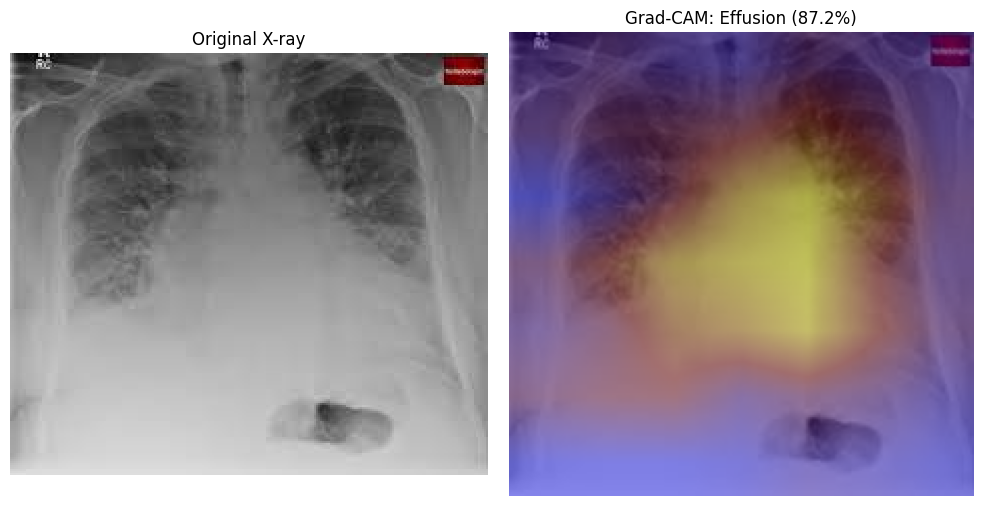

Top 5 findings:
  Effusion             87.2%
  Edema                85.9%
  Pneumonia            83.7%
  Cardiomegaly         81.1%
  Consolidation        79.3%
Flagged (>=50%): {'Atelectasis': 0.6755229830741882, 'Cardiomegaly': 0.8111886382102966, 'Effusion': 0.8719915747642517, 'Infiltration': 0.7613160014152527, 'Nodule': 0.5838627815246582, 'Pneumonia': 0.8365901112556458, 'Consolidation': 0.7932557463645935, 'Edema': 0.8591814637184143, 'Pleural_Thickening': 0.5360811948776245}


In [42]:
custom_image_path = input("Path to a chest X-ray image file: ").strip()
if not os.path.exists(custom_image_path):
    print(f"File not found: {custom_image_path}")
else:
    result, original, overlay = diagnose(custom_image_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")
    
    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM: {result['top_finding']} ({result['top_probability']:.1%})")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print("Top 5 findings:")
    for name, p in list(result["findings"].items())[:5]:
        print(f"  {name:20s} {p:.1%}")
    print("Flagged (>=50%):", result["flagged"] or "none")

## 13. Conclusion & next steps

- This notebook trains a DenseNet-121 multi-label classifier to flag 14
  thoracic pathologies from a chest X-ray, and produces a Grad-CAM overlay
  so predictions are visually explainable rather than opaque numbers.
- **To reproduce published CheXNet-level results** (mean AUC ≈ 0.84 across
  the 14 findings), train for the full ~15-20 epochs on the complete
  112,120-image dataset with a GPU — this notebook's `EPOCHS = 5` default is
  a quick pipeline check, not a final training run.
- **Before trusting any output clinically:** validate against a held-out,
  ideally external, radiologist-labeled test set; calibrate the output
  probabilities; and treat this strictly as a second-opinion / triage aid.

**Further improvements to consider:**
- Try EfficientNet or a ViT backbone and compare AUCs.
- Add test-time augmentation for more stable predictions.
- Fine-tune per-class thresholds instead of a single global 0.5 cutoff (optimize on a validation set).
- Build a small Streamlit app around `diagnose()` for a clinician-friendly UI.
